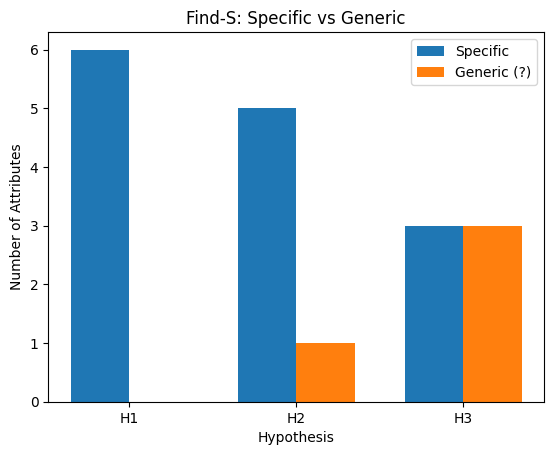

H1 = ['High', 'Good', 'Strong', 'Good', 'Technical', 'Paid']
H2 = ['High', 'Good', '?', 'Good', 'Technical', 'Paid']
H3 = ['High', 'Good', '?', '?', '?', 'Paid']
Final Hypothesis = ['High', 'Good', '?', '?', '?', 'Paid']


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Dataset
# Attributes:
# Skills, Projects, Coding, Communication, Interview, Internship
# Target: Selected

data = [
    ['High', 'Good',    'Strong', 'Good',    'Technical', 'Paid',   'Yes'],
    ['High', 'Good',    'Moderate', 'Good',  'Technical', 'Paid',   'Yes'],
    ['High', 'Poor',    'Weak',   'Poor',    'HR',        'Unpaid', 'No'],
    ['High', 'Good',    'Strong', 'Average', 'HR',        'Paid',   'Yes'],
    ['Medium', 'Poor',  'Weak',   'Average', 'HR',        'Unpaid', 'No']
]

# Find-S
h = ['0'] * 6
history = []

for row in data:

    # Process only positive examples
    if row[-1] == 'Yes':

        for i in range(6):

            if h[i] == '0':
                h[i] = row[i]

            elif h[i] != row[i]:
                h[i] = '?'

        # Store hypothesis after each positive example
        history.append(h.copy())


# Count specific and generic attributes
specific = [
    sum(x != '?' for x in h)
    for h in history
]

generic = [
    sum(x == '?' for x in h)
    for h in history
]


# Histogram
x = np.arange(len(history))
width = 0.35

plt.bar(
    x - width / 2,
    specific,
    width,
    label='Specific'
)

plt.bar(
    x + width / 2,
    generic,
    width,
    label='Generic (?)'
)

plt.xticks(
    x,
    [f'H{i + 1}' for i in range(len(history))]
)

plt.xlabel('Hypothesis')
plt.ylabel('Number of Attributes')
plt.title('Find-S: Specific vs Generic')

plt.legend()
plt.show()


# Display hypotheses
for i, h in enumerate(history):
    print(f"H{i + 1} =", h)

print("Final Hypothesis =", history[-1])